In [1]:
import Meshes as Meshes
using CairoMakie: CairoMakie as Makie
using Unitful: m, ustrip, Length
using LinearAlgebra: cross, dot, norm
using MarineHydro
using DifferentiationInterface 
import ForwardDiff 

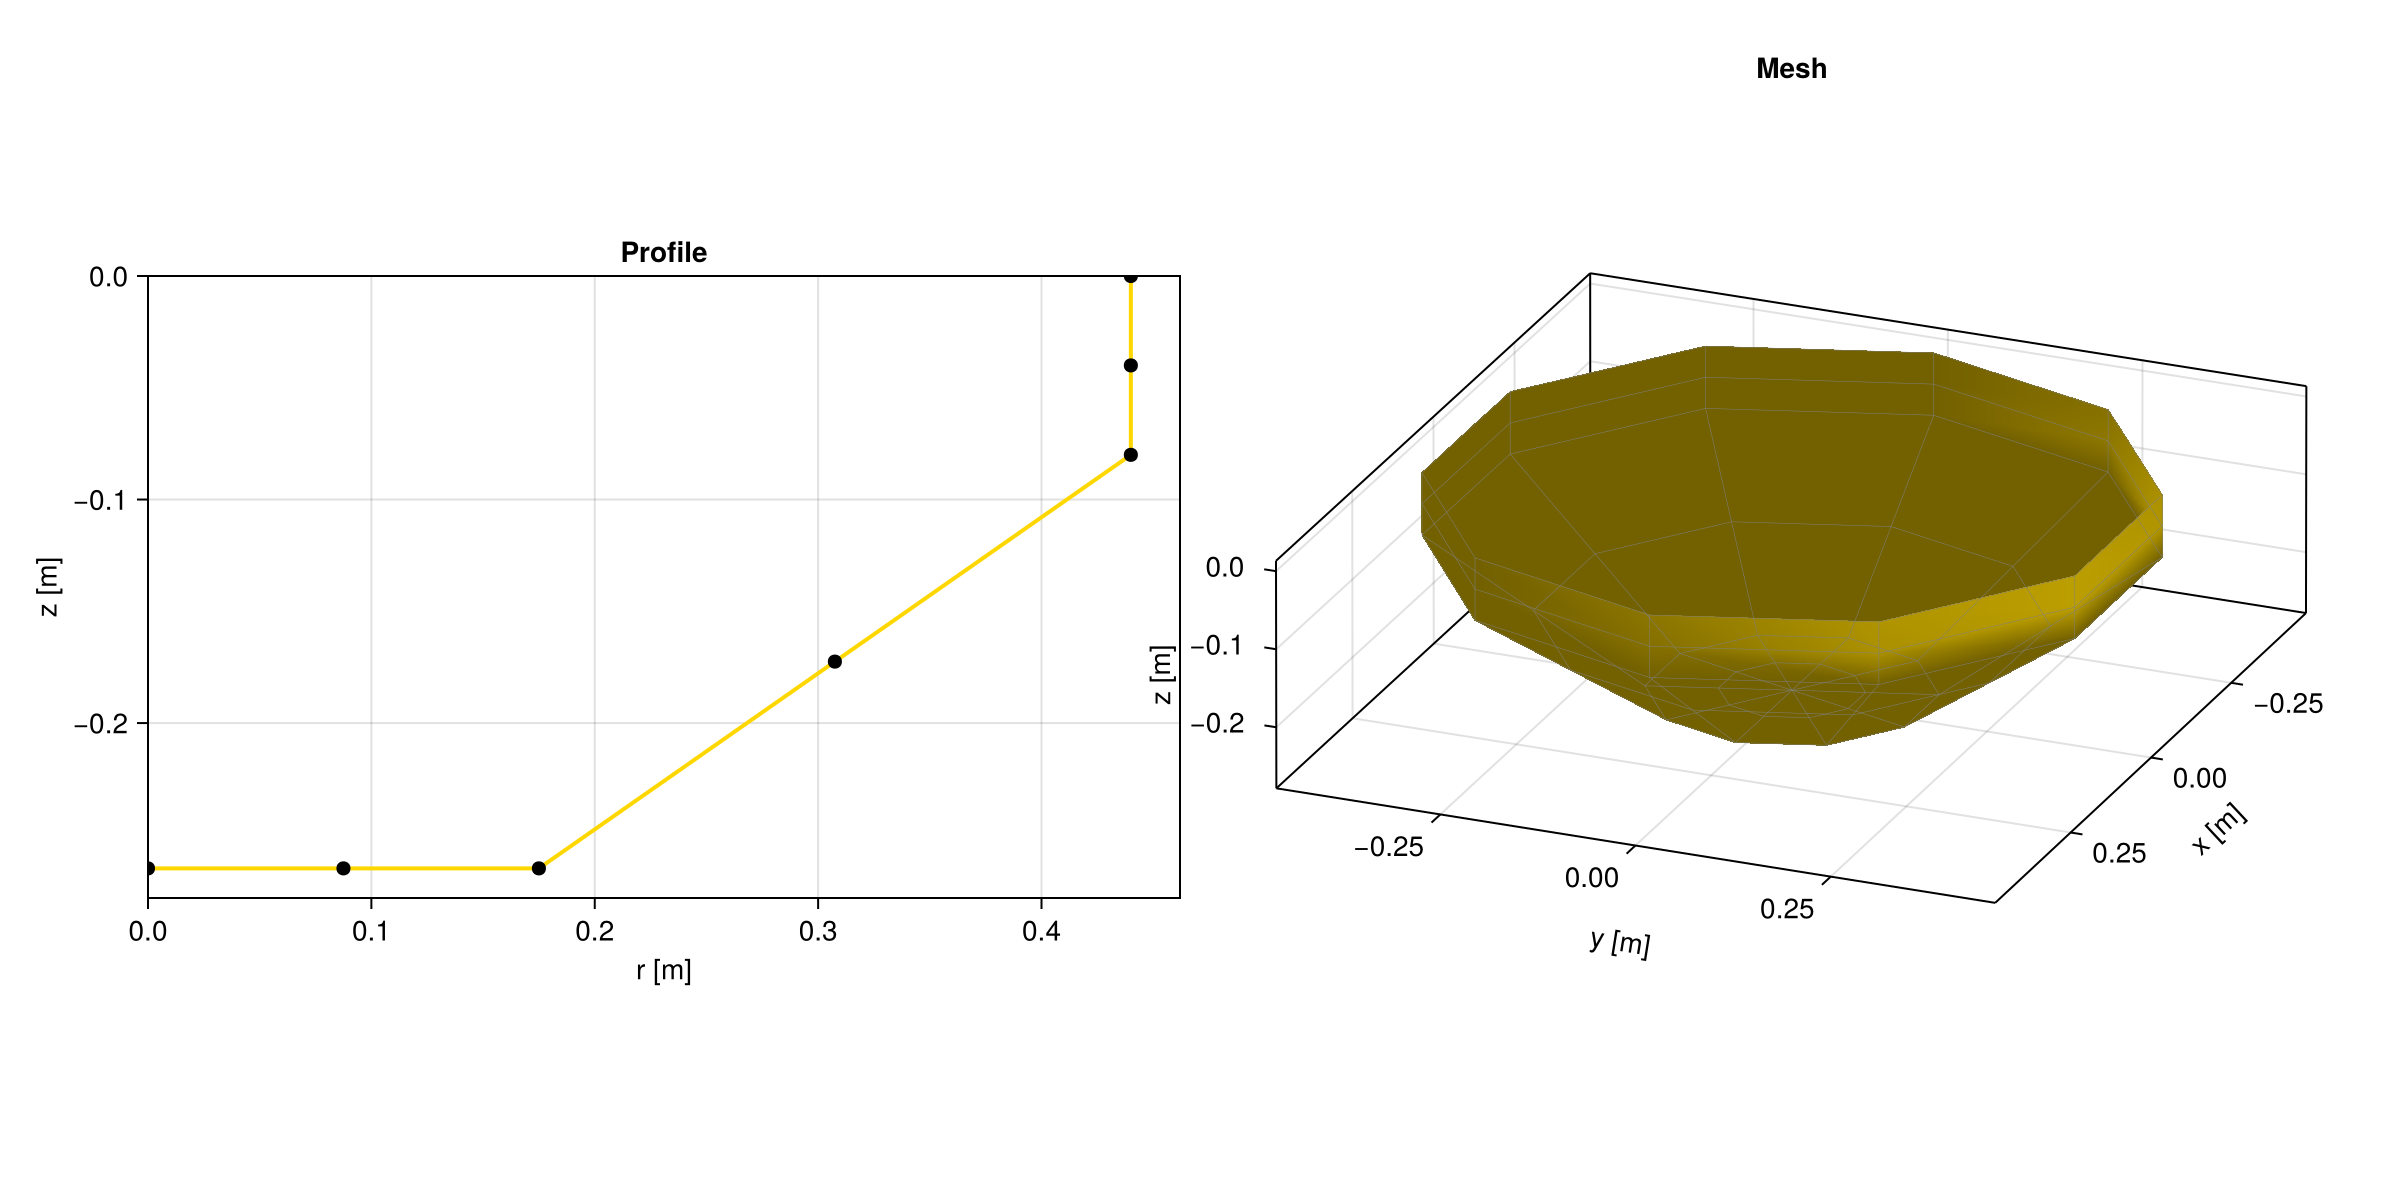

Mesh([0.44 0.0 -0.0; 0.35596747752497687 0.2586255110086882 -0.0; … ; 0.07078898700780789 -0.05143120957559141 -0.265; 0.0 0.0 -0.265], [0 10 11 1; 1 11 12 2; … ; 58 60 59 59; 59 60 50 50], Number[0.39798373876248844 0.1293127555043441 -0.02; 0.24596747752497689 0.3385451890892779 -0.020000000000000004; … ; 0.03260932467187192 -0.04488288491713912 -0.265; 0.05276299566926929 -0.01714373652519714 -0.265], Number[0.9510565162951536 0.3090169943749474 0.0; 0.587785252292473 0.8090169943749473 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.010877398201998149, 0.01087739820199815, 0.010877398201998147, 0.010877398201998147, 0.01087739820199815, 0.010877398201998149, 0.010877398201998149, 0.010877398201998147, 0.010877398201998147, 0.010877398201998154  …  0.0022501154189321234, 0.002250115418932123, 0.002250115418932123, 0.0022501154189321234, 0.0022501154189321234, 0.0022501154189321234, 0.002250115418932123, 0.002250115418932123, 0.002250115418932124, 0.0022501154189321242], Number[0.1374305458

In [38]:
# r1 = 0.88
# r2 = 0.35
# d1 = 0.16
# d2 = 0.37
r1 = 0.88/2
r2 = 0.35/2
d1 = 0.16/2
d2 = 0.37/2
n_points = (3, 3, 3)
n_theta = 10
show_plot = true


mhmesh = wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)

In [39]:
function wb_mesh(x)
    r1=x[1]
    r2=x[2]
    d1=x[3]
    d2=x[4]
    n_points=(3, 3, 3)
    n_theta = 10
    show_plot = false
    return wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)
end
x_wb = [r1,r2,d1,d2]
wb_mesh(x_wb)

Mesh([0.44 0.0 -0.0; 0.35596747752497687 0.2586255110086882 -0.0; … ; 0.07078898700780789 -0.05143120957559141 -0.265; 0.0 0.0 -0.265], [0 10 11 1; 1 11 12 2; … ; 58 60 59 59; 59 60 50 50], Number[0.39798373876248844 0.1293127555043441 -0.02; 0.24596747752497689 0.3385451890892779 -0.020000000000000004; … ; 0.03260932467187192 -0.04488288491713912 -0.265; 0.05276299566926929 -0.01714373652519714 -0.265], Number[0.9510565162951536 0.3090169943749474 0.0; 0.587785252292473 0.8090169943749473 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.010877398201998149, 0.01087739820199815, 0.010877398201998147, 0.010877398201998147, 0.01087739820199815, 0.010877398201998149, 0.010877398201998149, 0.010877398201998147, 0.010877398201998147, 0.010877398201998154  …  0.0022501154189321234, 0.002250115418932123, 0.002250115418932123, 0.0022501154189321234, 0.0022501154189321234, 0.0022501154189321234, 0.002250115418932123, 0.002250115418932123, 0.002250115418932124, 0.0022501154189321242], Number[0.1374305458

In [4]:
Int(round(0.1))

0

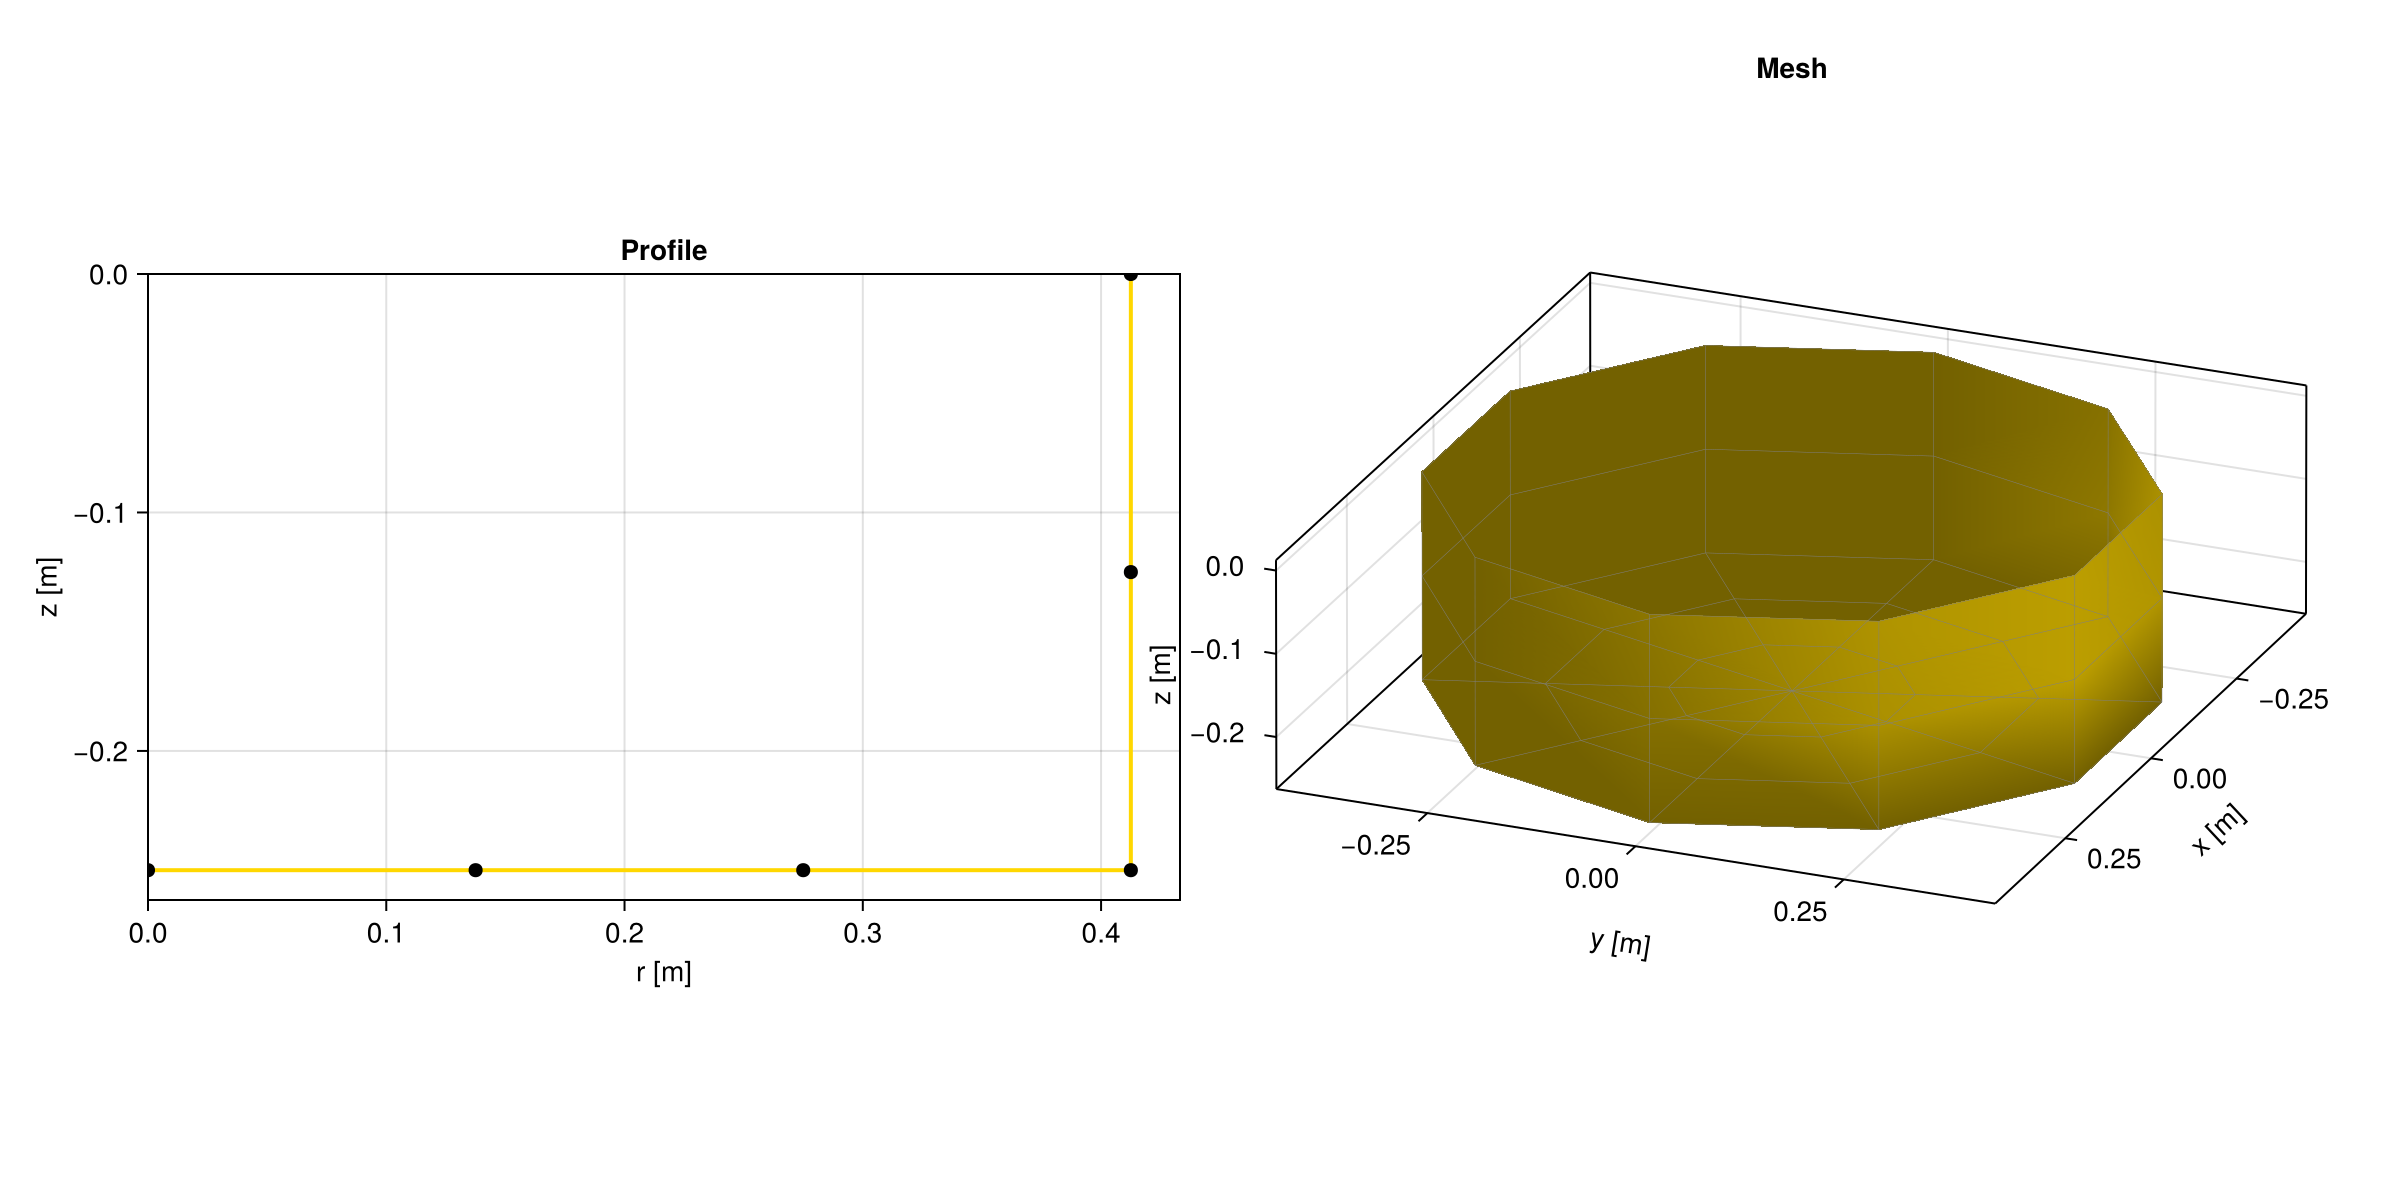

Mesh([0.41250000000000003 0.0 0.0; 0.33371951017966583 0.24246141657064518 0.0; … ; 0.11123983672655527 -0.0808204721902151 -0.25; 0.0 0.0 -0.25], [0 10 11 1; 1 11 12 2; … ; 48 50 49 49; 49 50 40 40], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.05124322448437017 -0.07053024772693291 -0.25; 0.08291327890885176 -0.026940157396738367 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.005556407463077286, 0.005556407463077286, 0.005556407463077286, 0.005556407463077286, 0.005556407463077287, 0.005556407463077286, 0.005556407463077284, 0.005556407463077286, 0.005556407463077286, 0.0055564074630772885], Number[0.1419673414044368

In [5]:
radii_upper = 1.0
radii_lower = 0.1
draft_upper = 2.0
draft_lower = 0.25



r_initial = 0.5
n_side = 4-1 # number of design vars-1 (draft is also a design var)

# inputs
# r_side = ones(n_side) * r_initial
# r_side = collect(range(0.5, 0.001, length=n_side)) # last radius cannot be zero
draft = draft_lower
r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75
x_val = vcat(r_side,draft)

# r_side = ones(n_side) * (radii_upper+radii_lower)/2 
# draft_nom = (draft_lower+draft_upper)/2
# x_val = vcat(r_side,draft)




function arbitrary_axisymmetric_mesh(x::Vector, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-0.0, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x::Vector) = arbitrary_axisymmetric_mesh(x, false)

arbitrary_axisymmetric_mesh(x_val, true)

In [6]:
MH_mesh = arbitrary_axisymmetric_mesh(x_val)

Mesh([0.41250000000000003 0.0 0.0; 0.33371951017966583 0.24246141657064518 0.0; … ; 0.11123983672655527 -0.0808204721902151 -0.25; 0.0 0.0 -0.25], [0 10 11 1; 1 11 12 2; … ; 48 50 49 49; 49 50 40 40], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.05124322448437017 -0.07053024772693291 -0.25; 0.08291327890885176 -0.026940157396738367 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.005556407463077286, 0.005556407463077286, 0.005556407463077286, 0.005556407463077286, 0.005556407463077287, 0.005556407463077286, 0.005556407463077284, 0.005556407463077286, 0.005556407463077286, 0.0055564074630772885], Number[0.1419673414044368

In [7]:
backend = AutoForwardDiff()

function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end

function compute_SA_and_gradient(x_val)
    return value_and_gradient(x -> surface_area(x), backend, x_val)
end

compute_SA_and_gradient (generic function with 1 method)

In [8]:
# compute_SA_and_gradient(x_val)

In [9]:
theoretical_SA = pi * r_initial * sqrt(draft^2 + r_initial^2)

0.8781018413800908

In [10]:
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

hydrostatic_program (generic function with 1 method)

In [32]:


# Hydrostatics
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

# Radiation
function radiation_program(mesh, omega, dof) 
    A, B = calculate_radiation_forces(mesh,dof,omega)
    # display("Damping: $B")
    return [A, B]
end

# Diffraction
function diffraction_program(mesh, omega, dof) 
    F_D = DiffractionForce(mesh,omega,dof)
    return [real(F_D),imag(F_D)]
end

function incident_program(mesh, omega, dof) 
    F_FK = FroudeKrylovForce(mesh,omega,dof)
    return [real(F_FK),imag(F_FK)]
end

# Everything
dof = [0.0,0.0,1.0]

function compute_for_omega(mesh, omega)

    # M, K = hydrostatic_program(r1, r2, d1, d2)
    A, B = radiation_program(mesh, omega, dof)
    F_D_real, F_D_imag = diffraction_program(mesh, omega, dof) 
    F_FK_real, F_FK_imag = incident_program(mesh, omega, dof)
    # add negatives to imag since wot uses +i omega t instead of -i omega t
    return [A, B, F_D_real, -F_D_imag, F_FK_real, -F_FK_imag]
end

backend = AutoForwardDiff()


function arbitrary_axisymmetric_mesh(x, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-1e-3, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x) = arbitrary_axisymmetric_mesh(x, false)


function compute_vals(x, omegas)
    set_rho!(1025.0)
    x=vec(x)
    mesh = arbitrary_axisymmetric_mesh(x)    
    M_val, K_val = hydrostatic_program(x)
    results_per_omega = [compute_for_omega(mesh, omega) for omega in omegas]
    vec_reduced = reduce(vcat, results_per_omega)
    
    return [M_val; K_val; vec_reduced]
end

function compute_all(x_val, omegas)
    return value_and_jacobian(x -> compute_vals(x, omegas), backend, x_val)
end


function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end


function centers(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(abs.(MH_mesh.centers[:,1]))
end

function compute_SA_and_gradient(x_val)
    return value_and_gradient(x -> surface_area(x), backend, x_val)
end

compute_SA_and_gradient (generic function with 1 method)

In [12]:
2*pi*0.3

1.8849555921538759

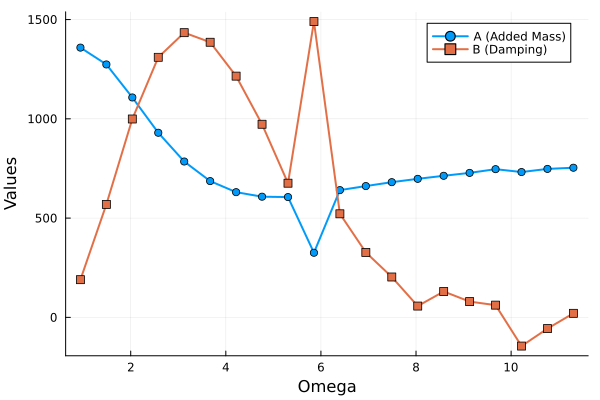

In [31]:
using Plots

omega = 2*pi*0.3


num_omegas = 20
omegas = collect(range(omega/2,6*omega,length=num_omegas))
dof = [0.0,0.0,1.0]

A = zeros(num_omegas)
B = zeros(num_omegas)

for i in 1:num_omegas
    omega = omegas[i]    
    A[i], B[i] = radiation_program(mhmesh, omega, dof)
end

plot(omegas, A, label="A (Added Mass)", xlabel="Omega", ylabel="Values", linewidth=2, marker=:circle)
plot!(omegas, B, label="B (Damping)", linewidth=2, marker=:square)    

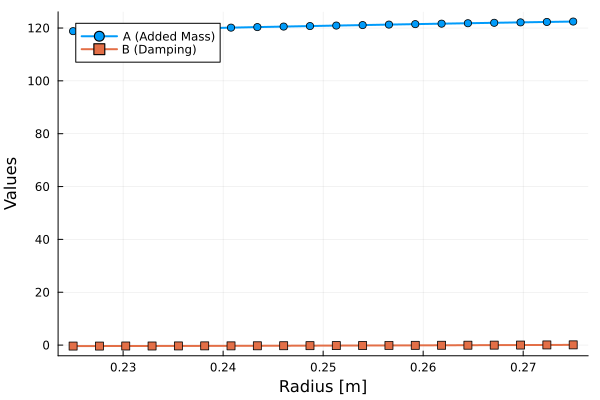

In [30]:
rad = (radii_upper+radii_lower)/2 * 0.75
r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75

num_r = 20
# r_vals = collect(range(0.9*rad,1.1*rad,length=num_r))
d_vals = collect(range(0.9*draft_lower,1.1*draft_lower,length=num_r))
dof = [0.0,0.0,1.0]



A = zeros(num_r)
B = zeros(num_r)

for i in 1:num_r  
    draft = d_vals[i]
    # r_side[end] = r_vals[i]
    x_new = vcat(r_side,draft) 
    new_mesh = arbitrary_axisymmetric_mesh(x_new)
    A[i], B[i] = radiation_program(new_mesh, omega, dof)
end

plot(d_vals, A, label="A (Added Mass)", xlabel="Radius [m]", ylabel="Values", linewidth=2, marker=:circle)
plot!(d_vals, B, label="B (Damping)", linewidth=2, marker=:square)  

In [15]:
all_out = compute_all(x_val, [omega, 2*omega])

([136.43349073102559, 5375.150779403056, 120.83591520318116, -0.20520190113003647, 59.04609444411077, -4.318591685922938, -31.002906317725966, 6.439293542825908e-15, 120.28897049917241, 0.05144465646491439, -5.130199073709078, -0.23745234164715792, -0.0017495388615012158, 2.520770051028798e-18], [165.37392815881884 330.7478563176377 165.37392815881884 547.9256655864481; 26061.337112257235 0.0 0.0 0.0; … ; 815.4422928172096 -814.2398454625511 -1.080491945985389 0.09124715333645057; -4.973799150320701e-14 4.9654724776360126e-14 1.4333152720258369e-16 -2.2551405187698492e-17])

In [16]:
all_out[2]

14×4 Matrix{Float64}:
   165.374         330.748          165.374        547.926
 26061.3             0.0              0.0            0.0
   -56.2144        150.795          747.893         71.793
   -89.424          47.2057           6.45872        9.99071
  -736.397        8318.73         -7782.8          -21.167
 -2784.17         2122.35           157.745        292.184
 -1463.49         1176.7            121.318        404.239
     9.09495e-13    -7.67386e-13     -9.9476e-14     3.19744e-14
    28.0741         91.028          719.298         60.1252
    -9.65258        27.6014          -4.74851       -0.792043
 -1069.14          -97.4056          47.2275        52.8577
   -17.6847        -25.6308          -0.304391       7.76567
   815.442        -814.24            -1.08049        0.0912472
    -4.9738e-14      4.96547e-14      1.43332e-16   -2.25514e-17

In [17]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, x -> compute_vals(x, [omega, 2*omega]), x_val)[1]


14×4 Matrix{Float64}:
   165.374         330.748         165.374        547.926
 26061.3            -1.06007e-9     -1.54766e-9    -6.79118e-10
   -55.744         224.339         673.879         71.793
  -124.502          69.6394         19.1028         9.99071
  -944.864         880.607        -136.2          -21.167
 -3094.53         2118.42          472.033        292.184
 -1463.49         1176.7           121.318        404.239
    -2.42365e-11    -5.52119e-12    -1.52147e-10    4.08974e-11
    34.6088        169.899         633.893         60.1252
   -11.6306         25.626          -0.795092      -0.792043
 -1096.58          -94.9346         72.1948        52.8577
   -15.3903        -26.1849         -2.04475        7.76567
   815.442        -814.24           -1.08049        0.0912472
     2.82444e-12     1.33396e-12    -1.07315e-14   -1.22785e-14

In [18]:
# J

In [19]:
SA_grad = value_and_gradient(x -> surface_area(x), backend, x_val)

(1.1374242225752862, [0.3862712429686843, 0.7725424859373686, 2.810885408675137, 2.5493902035933163])

In [20]:
SA_grad[2]

4-element Vector{Float64}:
 0.3862712429686843
 0.7725424859373686
 2.810885408675137
 2.5493902035933163

In [21]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.grad(method, x -> surface_area(x), x_val)[1]


4-element Vector{Float64}:
 0.3862712429688895
 0.772542485937237
 2.8108854086752895
 2.549390203593285

In [36]:
centers(x_val)
centers_grad = value_and_gradient(x -> centers(x), backend, x_val)
centers_grad[2]

4-element Vector{Float64}:
  2.9270509831248424
  5.854101966249683
 12.206886692587311
 -1.5543122344752192e-15

In [37]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.grad(method, x -> centers(x), x_val)[1]

4-element Vector{Float64}:
  2.927050983126427
  5.854101966248544
 12.206886692592693
  5.5399110039547584e-14

In [22]:
#verify derivatives wrt omega work?
der_wrt_omega = derivative(o -> compute_for_omega(MH_mesh, o), backend, omega)

6-element Vector{Float64}:
   0.5235928937453558
  -2.076110473005797
 -36.44274331369656
 -22.325833763011463
  16.76609922669094
  -3.552713678800501e-15

In [23]:
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, o -> compute_for_omega(MH_mesh, o), omega)[1]


6×1 Matrix{Float64}:
   0.523592895681594
  -2.0761104711012957
 -36.442743260448026
 -22.325833727739354
  16.76609922677149
  -8.028816800031681e-14

In [24]:
function wb_coeffs(x_wb,omega)
    mesh = wb_mesh(x_wb)
    return compute_for_omega(mesh, omega)
end

wb_coeffs (generic function with 1 method)

In [40]:
wb_jac = value_and_jacobian(x -> wb_coeffs(x,omega), backend, x_wb)
wb_jac[2]

6×4 Matrix{Float64}:
    639.367         -30.9306        241.497        -123.35
   -613.918          25.2192       -474.531         -50.4133
 -11876.5          -612.884       -2526.87         -526.517
   4648.91          178.641        2226.03          349.078
    337.949         727.8          2305.28          601.767
     -3.69482e-13    -2.4869e-13     -6.82121e-13    -1.84741e-13

In [41]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, x -> wb_coeffs(x,omega), x_wb)[1]


6×4 Matrix{Float64}:
    639.367         -30.9306         241.497        -123.35
   -613.918          25.2192        -474.531         -50.4133
 -11876.5          -612.884        -2526.87         -526.517
   4648.91          178.641         2226.03          349.078
    337.949         727.8           2305.28          601.767
     -4.40609e-10     8.62183e-10      6.65331e-11    -8.63502e-10